In [1]:
from sklearn.datasets import make_regression
import pandas as pd 
import numpy as np 
import plotly.express as px 
import plotly.graph_objects as go 
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score
import matplotlib.pyplot as plt



In [2]:
x,y = make_regression(n_samples=100,n_features=2,n_informative=2,n_targets = 1,noise=50)

In [3]:
df = pd.DataFrame({'feature1':x[:,0],'feature2':x[:,1],'target':y})

In [4]:
df.head()

,feature1,feature2,target
0,-0.130924,0.098479,-73.941447
1,-0.406446,-0.606733,-98.745031
2,-1.168008,0.279895,33.078361
3,0.823313,0.221664,65.908788
4,-1.086370,-1.067371,-161.443399


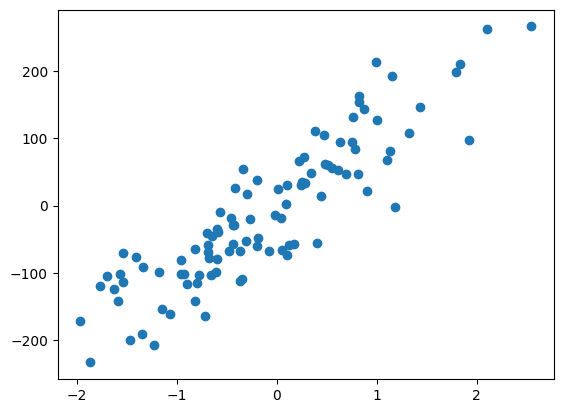

In [5]:
plt.scatter(df['feature2'],df['target'])

In [6]:
fig =  px.scatter_3d(df,x=df['feature1'],y=df['feature2'],z=df['target'])
fig.show()

In [7]:
x = df.drop('target',axis = 1)
y = df['target']

In [8]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [9]:
from sklearn.linear_model import LinearRegression

In [10]:
lr = LinearRegression()

In [11]:
lr.fit(x_train,y_train)
y_pred = lr.predict(x_test)

In [12]:
print('MAE',mean_absolute_error(y_test,y_pred))
print('MSE',mean_squared_error(y_test,y_pred))
print('R2 score',r2_score(y_test,y_pred))

MAE 39.086590348970745
MSE 2579.6512481175914
R2 score 0.6636008002031589


In [13]:
x = np.linspace(-5, 5, 10)
y = np.linspace(-5, 5, 10)

xgrid, ygrid = np.meshgrid(x, y)

# FIX: correct shape
final = np.column_stack((xgrid.ravel(), ygrid.ravel()))

z_final = lr.predict(final).reshape(10, 10)

fig = px.scatter_3d(df, x='feature1', y='feature2', z='target')
fig.add_surface(x=xgrid, y=ygrid, z=z_final)
fig.show()


/opt/anaconda3/lib/python3.12/site-packages/sklearn/base.py:465: UserWarning:

X does not have valid feature names, but LinearRegression was fitted with feature names



In [14]:
lr.coef_


array([22.05915536, 99.18136566])

In [15]:
lr.intercept_

-2.932635408139756